# 01 · Exploración con SQL

**Objetivo del notebook:** responder con consultas SQL las primeras preguntas de cualquier proyecto de monitoreo transaccional (qué tan raro es el fraude, si la velocidad o el desvío del monto lo delatan) y construir en SQL las variables de comportamiento por tarjeta que usa el modelo.

In [1]:
# ==========================================================
# Conexión
# ==========================================================

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fraude import base_datos as bd, config, datos, graficos

graficos.estilo()

conn = bd.conectar()
print(f"Conexión exitosa a {config.BASE.name}")

Conexión exitosa a ieee_fraud.sqlite


In [2]:
# ==========================================================
# Balance de clases y monto promedio por clase
# ==========================================================

# ------------------------------------------------------------------------------
# Query 1: Panorama general del fraude
# Primera pregunta en cualquier proyecto de monitoreo transaccional: ¿qué tan raro es el fraude
# y en qué se diferencian los montos entre clases?
# ------------------------------------------------------------------------------

query = """
SELECT
    isFraud,
    COUNT(*) AS total_transacciones,
    ROUND(CAST(COUNT(*) AS FLOAT)/
        (SELECT COUNT(*) FROM transactions)*100, 2) AS proporcion_pct,
    ROUND(AVG(TransactionAmt), 2) AS monto_promedio,
    ROUND(MIN(TransactionAmt), 2) AS monto_minimo,
    ROUND(MAX(TransactionAmt), 2) AS monto_maximo,
    ROUND(SUM(TransactionAmt), 2) AS monto_total
FROM transactions
GROUP BY isFraud
"""

df = pd.read_sql_query(query, conn)
df

,isFraud,total_transacciones,proporcion_pct,monto_promedio,monto_minimo,monto_maximo,monto_total
0,0,569877,96.5,134.51,0.25,31937.39,76655103.88
1,1,20663,3.5,149.24,0.29,5191.00,3083844.86


Se puede observar a partir de estos números que el fraude representa solo el 3.5% de las transacciones, lo que confirma un desbalance de clases que se debe tener en cuenta para la generación del modelo predictivo.

Adicionalmente, se observa que el monto promedio de fraude es ligeramente mayor al de transacciones legítimas, aunque la diferencia no es dramática. Lo más relevante en este caso es el monto máximo: vemos cómo las transacciones legítimas pueden llegar a $31,937 mientras que el fraude tiene un techo en $5,191, lo cual sugiere que el fraude no se concentra en transacciones de alto valor, sino en montos medianos que pueden pasar desapercibidos.

In [3]:
# ------------------------------------------------------------------------------
# Query 2: Detección de alta frecuencia transaccional
# Una tarjeta con muchas transacciones en poco tiempo es una señal clásica de monitoreo transaccional.
# TransactionDT es un delta en segundos desde un punto de referencia,
# no un timestamp real — pero sirve para calcular distancias entre transacciones.
# ------------------------------------------------------------------------------
query = """
    WITH actividad_tarjeta AS (
    SELECT card1,
           COUNT(*)                         AS total_tx,
           SUM(isFraud)                     AS total_fraudes,
           ROUND(AVG(TransactionAmt), 2)    AS monto_promedio,
           MAX(TransactionDT) - MIN(TransactionDT) AS rango_tiempo_seg,
           ROUND(CAST(COUNT(*) AS FLOAT) /
                 NULLIF((MAX(TransactionDT) - MIN(TransactionDT)), 0)
                 * 3600, 4)                 AS tx_por_hora
    FROM transactions
    GROUP BY card1
)

    SELECT
        *,
        ROUND(CAST(total_fraudes AS FLOAT) / total_tx * 100, 2) AS tasa_fraude_pct
    FROM actividad_tarjeta
    WHERE total_tx >= 5
    ORDER BY tx_por_hora DESC
    LIMIT 15
"""

df = pd.read_sql_query(query, conn)
df

,card1,total_tx,total_fraudes,monto_promedio,rango_tiempo_seg,tx_por_hora,tasa_fraude_pct
0,11854,5,0,150.00,271,66.4207,0.0
1,6945,6,0,1711.27,602,35.8804,0.0
2,9971,5,0,30.00,503,35.7853,0.0
3,8277,5,0,76.61,512,35.1563,0.0
4,13191,7,0,103.77,874,28.8330,0.0
5,3233,5,0,38.01,694,25.9366,0.0
6,12273,5,0,200.00,783,22.9885,0.0
7,4307,5,0,470.00,1039,17.3244,0.0
8,4623,5,0,28.51,1210,14.8760,0.0
9,12593,6,0,58.33,1542,14.0078,0.0


Las tarjetas con mayor velocidad, de hasta 66 transacciones por hora, tienen una tasa de fraude del 0%. Este es un hallazgo importante, ya que la alta frecuencia por sí sola no es señal de fraude en este set de datos, y podría indicar que se trata de tarjetas corporativas de alto volumen legítimo.

En conclusión, la velocidad transaccional como característica aislada tiene poco poder predictivo, por lo que sería necesario combinarla con otras variables, como el z-score del monto o el dominio de email, para que sea útil.

In [4]:
# ------------------------------------------------------------------------------
# Query 3: Transacciones anómalas por desviación del comportamiento histórico
# Una transacción que se aleja mucho del promedio histórico de esa tarjeta
# es más sospechosa que una de monto absoluto alto.
# El z-score mide exactamente eso: cuántas desviaciones estándar se aleja
# una transacción del comportamiento normal de esa tarjeta.
# ------------------------------------------------------------------------------
query = """
WITH perfil_tarjeta AS (
    SELECT card1,
           AVG(TransactionAmt)                                    AS avg_monto,
           SQRT(AVG(TransactionAmt * TransactionAmt) -
                AVG(TransactionAmt) * AVG(TransactionAmt))        AS std_monto
    FROM transactions
    GROUP BY card1
)
SELECT t.TransactionID,
       t.card1,
       t.TransactionAmt,
       ROUND(p.avg_monto, 2)   AS promedio_tarjeta,
       ROUND(p.std_monto, 2)   AS std_tarjeta,
       ROUND((t.TransactionAmt - p.avg_monto) /
             NULLIF(p.std_monto, 0), 2) AS z_score,
       t.isFraud
FROM transactions t
JOIN perfil_tarjeta p ON t.card1 = p.card1
WHERE ABS((t.TransactionAmt - p.avg_monto) /
          NULLIF(p.std_monto, 0)) > 3
ORDER BY ABS((t.TransactionAmt - p.avg_monto) /
             NULLIF(p.std_monto, 0)) DESC
LIMIT 20
"""

df = pd.read_sql_query(query, conn)
df

,TransactionID,card1,TransactionAmt,promedio_tarjeta,std_tarjeta,z_score,isFraud
0,3261336,16075,31937.391,279.85,857.68,36.91,0
1,3261339,16075,31937.391,279.85,857.68,36.91,0
2,3158451,9500,5278.950,115.70,193.37,26.70,0
3,3409708,9500,5191.000,115.70,193.37,26.25,1
4,3345581,15775,1560.570,107.42,57.74,25.17,0
5,3262529,5033,5420.000,107.14,218.46,24.32,0
6,3262535,5033,5420.000,107.14,218.46,24.32,0
7,3520410,9500,4299.360,115.70,193.37,21.64,0
8,3520550,9500,4299.360,115.70,193.37,21.64,0
9,3283021,16661,6450.970,150.89,292.45,21.54,0


A partir de estos datos podemos evidenciar que las transacciones con z-score mayor a 3 son las que se alejan del comportamiento histórico de esa tarjeta. Lo interesante es que, de las top 20 transacciones más anómalas por z-score, solo 2 son fraude, por lo que se refuerza la conclusión de que ninguna de las variables por sí sola tiene la capacidad de discriminar bien el fraude, siendo este el motivo por el que se necesita un modelo de ML que funcione con la combinación de múltiples señales y no de una sola variable fuerte.

## De la exploración a las variables del modelo

Las consultas 2 y 3 dejan dos limitaciones para llevar estas señales al modelo. La primera es que card1 no identifica una tarjeta sino un grupo de tarjetas: como muestra la Query 4, en la base hay 13,553 valores distintos de card1 para 590,540 transacciones, es decir, 43.6 transacciones por valor en promedio, por lo que la velocidad y el z-score anteriores mezclan el comportamiento de muchos clientes. La segunda es que el perfil de la Query 3 usa todo el historial de la tarjeta, incluidas las transacciones posteriores, de modo que el z-score de una transacción incorpora información que no existía en el momento de autorizarla, lo cual dentro de un modelo sería una fuga de datos (Kaufman et al., 2012).

Para resolver ambas, el script `src/fraude/sql/features_tarjeta.sql` aproxima la tarjeta individual combinando card1 a card6, la dirección de facturación (addr1) y el día de inicio de la relación con la tarjeta, que se obtiene restando D1 al día de la transacción, estrategia que usó el equipo ganador de la competencia (McDonald & Deotte, 2021). Sobre esa tarjeta aproximada, las funciones de ventana calculan cada variable solo con las transacciones anteriores, que es la forma en que se agregan las variables de comportamiento en la detección de fraude con tarjetas (Whitrow et al., 2009; Correa Bahnsen et al., 2016). Adicionalmente, se agrega una bandera de registro de identidad, ya que la tabla identity cubre solo el 24.4% de las transacciones y, aunque sus columnas tengan demasiados nulos para usarse directamente, su presencia o ausencia puede ser informativa en sí misma.

In [5]:
# ------------------------------------------------------------------------------
# Query 4: ¿Qué tan bien identifica card1 a una tarjeta?
# Si card1 fuera un identificador de tarjeta, tendría casi tantos valores
# distintos como tarjetas; la tabla identity cubre solo una parte de las
# transacciones, lo que define cuánta información aporta la unión.
# ------------------------------------------------------------------------------
query = """
SELECT
    COUNT(*)                                   AS transacciones,
    COUNT(DISTINCT card1)                      AS valores_card1,
    ROUND(CAST(COUNT(*) AS FLOAT) / COUNT(DISTINCT card1), 1) AS tx_por_card1,
    (SELECT COUNT(*) FROM identity)            AS con_identidad,
    ROUND(100.0 * (SELECT COUNT(*) FROM identity) / COUNT(*), 1) AS pct_con_identidad
FROM transactions
"""

pd.read_sql_query(query, conn)

,transacciones,valores_card1,tx_por_card1,con_identidad,pct_con_identidad
0,590540,13553,43.6,144233,24.4


In [6]:
# ------------------------------------------------------------------------------
# Query 5: Variables de comportamiento por tarjeta (funciones de ventana)
# El script vive en src/fraude/sql/features_tarjeta.sql para que el notebook 03
# y cualquier otro proceso usen exactamente la misma definición.
# ------------------------------------------------------------------------------
print(bd.leer_sql('features_tarjeta'))

inicio = time.perf_counter()
n = datos.crear_features(conn, forzar=True)
print(f"Tabla features_tarjeta: {n:,} filas creadas en {time.perf_counter() - inicio:.1f} s")

pd.read_sql_query("SELECT * FROM features_tarjeta WHERE tx_previas >= 3 LIMIT 5", conn)

-- =============================================================================
-- Variables de comportamiento por tarjeta
-- Cada variable se calcula solo con las transacciones ANTERIORES de la misma
-- tarjeta (marcos de ventana que terminan en 1 PRECEDING), de modo que el valor
-- que recibe una transacción es el que se conocería en el momento de autorizarla.
-- Ninguna variable usa isFraud, por lo que no hay fuga de la etiqueta.
-- =============================================================================
DROP TABLE IF EXISTS features_tarjeta;

CREATE TABLE features_tarjeta AS
WITH base AS (
    SELECT
        t.TransactionID,
        t.TransactionDT,
        t.TransactionAmt,
        -- El dataset no trae un identificador de tarjeta. Se aproxima con las
        -- variables de la tarjeta (card1 a card6), la dirección de facturación
        -- (addr1) y el día en que empezó la relación con la tarjeta, que se
        -- obtiene restando D1 (días desde el inicio) al día de la tra

Tabla features_tarjeta: 590,540 filas creadas en 9.7 s


,TransactionID,tarjeta,tiene_identidad,tx_previas,seg_desde_anterior,tx_1h,tx_24h,monto_24h,monto_prom_previo,z_monto_previo,ratio_monto_previo
0,3337822,10003-555.0-128.0-226.0-visa-debit-na-90,1,3,7190,0,2,29.848,23.080667,-0.331559,0.827229
1,3167957,10009-363.0-150.0-226.0-visa-debit-204-36,0,3,3323,1,3,728.000,242.666667,-1.226486,0.461538
2,3168012,10009-363.0-150.0-226.0-visa-debit-204-36,0,4,1114,1,4,840.000,210.000000,-0.984004,0.492857
3,3201976,10009-363.0-150.0-226.0-visa-debit-204-36,0,5,1022119,0,0,0.000,188.700000,1.335997,1.748808
4,3203219,10009-363.0-150.0-226.0-visa-debit-204-36,0,6,19519,0,1,330.000,212.250000,1.616267,1.837456


In [7]:
# ------------------------------------------------------------------------------
# Query 6: ¿Qué tan consistente es la etiqueta dentro de una tarjeta?
# Si la etiqueta de fraude se repite en todas las transacciones de una tarjeta,
# el comportamiento por tarjeta es una señal fuerte y un corte aleatorio
# del dataset filtraría información entre entrenamiento y prueba.
# ------------------------------------------------------------------------------
query = """
WITH por_tarjeta AS (
    SELECT f.tarjeta,
           COUNT(*)       AS tx,
           AVG(t.isFraud) AS tasa_fraude
    FROM features_tarjeta f
    JOIN transactions t ON t.TransactionID = f.TransactionID
    GROUP BY f.tarjeta
)
SELECT
    COUNT(*)                                              AS tarjetas_aproximadas,
    ROUND(AVG(tx), 2)                                     AS tx_por_tarjeta,
    SUM(tasa_fraude > 0)                                  AS tarjetas_con_fraude,
    SUM(tasa_fraude = 1)                                  AS tarjetas_solo_fraude,
    ROUND(100.0 * SUM(CASE WHEN tasa_fraude > 0 THEN tx * tasa_fraude END)
          / SUM(CASE WHEN tasa_fraude > 0 THEN tx END), 1) AS pct_fraude_en_tarjetas_con_fraude,
    ROUND(100.0 * SUM(CASE WHEN tasa_fraude IN (0, 1) THEN tx END) / SUM(tx), 1)
                                                          AS pct_tx_en_tarjetas_de_una_clase
FROM por_tarjeta
"""

pd.read_sql_query(query, conn)

,tarjetas_aproximadas,tx_por_tarjeta,tarjetas_con_fraude,tarjetas_solo_fraude,pct_fraude_en_tarjetas_con_fraude,pct_tx_en_tarjetas_de_una_clase
0,222493,2.65,8199,5095,47.2,94.7


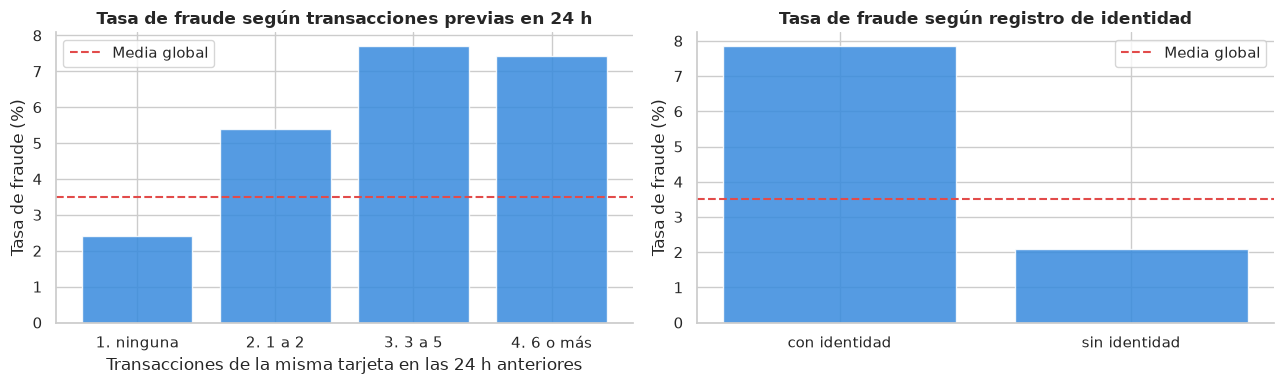

,tx_previas_24h,transacciones,tasa_fraude_pct
0,1. ninguna,420459,2.42
1,2. 1 a 2,109525,5.39
2,3. 3 a 5,32658,7.70
3,4. 6 o más,27898,7.43


,registro,transacciones,tasa_fraude_pct
0,con identidad,144233,7.85
1,sin identidad,446307,2.09


In [8]:
# ------------------------------------------------------------------------------
# Query 7: Tasa de fraude según las nuevas variables
# Velocidad en las últimas 24 horas e indicador de registro de identidad,
# ambos calculados solo con información previa a cada transacción.
# ------------------------------------------------------------------------------
query = """
SELECT
    CASE
        WHEN f.tx_24h = 0  THEN '1. ninguna'
        WHEN f.tx_24h <= 2 THEN '2. 1 a 2'
        WHEN f.tx_24h <= 5 THEN '3. 3 a 5'
        ELSE                    '4. 6 o más'
    END                                   AS tx_previas_24h,
    COUNT(*)                              AS transacciones,
    ROUND(100.0 * AVG(t.isFraud), 2)      AS tasa_fraude_pct
FROM features_tarjeta f
JOIN transactions t ON t.TransactionID = f.TransactionID
GROUP BY 1
ORDER BY 1
"""
velocidad = pd.read_sql_query(query, conn)

query = """
SELECT
    CASE f.tiene_identidad WHEN 1 THEN 'con identidad' ELSE 'sin identidad' END AS registro,
    COUNT(*)                              AS transacciones,
    ROUND(100.0 * AVG(t.isFraud), 2)      AS tasa_fraude_pct
FROM features_tarjeta f
JOIN transactions t ON t.TransactionID = f.TransactionID
GROUP BY 1
"""
identidad = pd.read_sql_query(query, conn)
conn.close()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(velocidad['tx_previas_24h'], velocidad['tasa_fraude_pct'], color=graficos.AZUL, alpha=0.85)
axes[0].axhline(3.5, color=graficos.ROJO, linestyle='--', lw=1.5, label='Media global')
axes[0].set_title('Tasa de fraude según transacciones previas en 24 h')
axes[0].set_xlabel('Transacciones de la misma tarjeta en las 24 h anteriores')
axes[0].set_ylabel('Tasa de fraude (%)')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].bar(identidad['registro'], identidad['tasa_fraude_pct'], color=graficos.AZUL, alpha=0.85)
axes[1].axhline(3.5, color=graficos.ROJO, linestyle='--', lw=1.5, label='Media global')
axes[1].set_title('Tasa de fraude según registro de identidad')
axes[1].set_ylabel('Tasa de fraude (%)')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
graficos.guardar(fig, '01_features_sql')
plt.show()

display(velocidad)
display(identidad)

La Query 6 confirma que la tarjeta aproximada se comporta como un cliente: las 590,540 transacciones se agrupan en 222,493 tarjetas, con 2.65 transacciones en promedio, y el 94.7% de las transacciones pertenece a tarjetas en las que todas sus transacciones tienen la misma etiqueta. Esto es consistente con la forma en que se construyó el dataset, ya que cuando una tarjeta reporta un contracargo sus transacciones posteriores vinculadas también se marcan como fraude (Vesta Corporation, 2019). Por esta razón el historial de la tarjeta es una señal fuerte y la partición del modelo debe ser cronológica, pues con una partición aleatoria transacciones de una misma tarjeta quedarían a la vez en entrenamiento y en prueba.

Adicionalmente, la Query 7 muestra que las nuevas variables sí separan el riesgo, a diferencia de las señales aisladas de las consultas 2 y 3. Las transacciones sin actividad previa de la tarjeta en las últimas 24 horas tienen una tasa de fraude de 2.42%, por debajo de la media global, mientras que con 3 a 5 transacciones previas la tasa sube a 7.70%, más del doble de la media. De igual forma, las transacciones con registro de identidad tienen una tasa de 7.85% frente a 2.09% de las que no lo tienen, por lo que la sola presencia del registro resulta ser una señal útil aunque sus columnas se excluyan por nulos.

## Conclusión

Los datos nos muestran cuatro hallazgos clave que guiarán el modelado:

- La presencia de fraude es rara y de montos moderados, por lo que se necesitará manejo de desbalance y métricas como PR-AUC, que con clases desbalanceadas es más informativa que la curva ROC (Saito & Rehmsmeier, 2015).
- Ninguna variable individual discrimina bien: ni el monto, ni la velocidad, ni las anomalías son suficientes por sí solas.
- El fraude es sutil, ya que usualmente opera en rangos de monto que no generan alertas automáticas, lo que hace indispensable un modelo que combine múltiples señales simultáneas.
- Las señales de comportamiento sí funcionan cuando se calculan por tarjeta y solo con su historial previo: la velocidad en 24 horas y el registro de identidad duplican la tasa de fraude en sus grupos de mayor riesgo, por lo que entran al modelo como variables construidas en SQL.

## Referencias

- Correa Bahnsen, A., Aouada, D., Stojanovic, A., & Ottersten, B. (2016). Feature engineering strategies for credit card fraud detection. *Expert Systems with Applications, 51*, 134–142. https://doi.org/10.1016/j.eswa.2015.12.030
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1–21. https://doi.org/10.1145/2382577.2382579
- McDonald, C., & Deotte, C. (2021, 26 de enero). *Leveraging machine learning to detect fraud: Tips to developing a winning Kaggle solution*. NVIDIA Technical Blog. https://developer.nvidia.com/blog/leveraging-machine-learning-to-detect-fraud-tips-to-developing-a-winning-kaggle-solution/
- Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432
- Vesta Corporation. (2019). *Data description (details and discussion)* [Publicación en foro]. Kaggle. https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203
- Whitrow, C., Hand, D. J., Juszczak, P., Weston, D., & Adams, N. M. (2009). Transaction aggregation as a strategy for credit card fraud detection. *Data Mining and Knowledge Discovery, 18*(1), 30–55. https://doi.org/10.1007/s10618-008-0116-z